## RNN: Thorcino ways

The aim of this notebook is to show how to train a classic RNN using this framework


In [8]:
import numpy as np

N = 1000
T = 5

def create_sequence(len: int, start: float, stop: float) -> np.ndarray:
    return np.linspace(start, stop, len)

def create_random_sequences(n: int, len:int, min_start: int=10, seed: float=777) -> np.ndarray:
    rng = np.random.default_rng(seed)
    sequences = []
    for _ in range(n):
        start = rng.integers(1, min_start, size=1)[0]
        stop = start * 3
        seq = create_sequence(len+1, start, stop)

        sequences.append(seq)

    return np.stack(sequences)

Train = create_random_sequences(N, T, min_start=30)
Train = Train.reshape(Train.shape[0], Train.shape[1], 1)
Test = create_random_sequences(N, T, min_start=45)
Test = Test.reshape(Train.shape[0], Train.shape[1], 1)

X_tr, Y_tr = Train[:, :-1], Train[:, 1:]
X_te, Y_te = Test[:, :-1], Test[:, 1:]

In [9]:
"""Model architecture"""

from thorcino.activations import Identity, ReLU
from thorcino.layers import Sequential, RNN
from thorcino.layers.linear import Linear
from thorcino.losses import MSELoss
from thorcino.optimizer import SGD
from thorcino.training.schedulers import CosineSchedule
from thorcino.training.trainer import Trainer 

EPOCHS = 50
IN_FEATURE = 1
OUT_FEATURE = 1
HIDDEN_UNITS = 2
MAX_LR, MIN_LR = 1e-5, 1e-8

model = Sequential(
    RNN(
        IN_FEATURE, 
        HIDDEN_UNITS, 
        activation_h=Identity(), 
        #activation_o=Identity()
    ),
    Linear(
        HIDDEN_UNITS,
        1
    )
)
model.save_graph("./images/arch.png", X_tr.shape, True)
model.save_graph("./images/forward.png", X_tr.shape, False, True)
model.save_graph("./images/backward.png", X_tr.shape, False, backward=True)

loss = MSELoss()
optimizer = SGD(model.parameters, MAX_LR, 0.7)
scheduler = CosineSchedule(MAX_LR, MIN_LR, EPOCHS)
trainer = Trainer(model, loss, optimizer, scheduler, 1e5)

In [10]:
"""Preprocessing"""

from thorcino.dataset import DataLoader, TensorDataset
from thorcino.tensor import Tensor

BATCH_SIZE = 16

X_tr, Y_tr = Tensor(X_tr), Tensor(Y_tr)
dataset_tr = TensorDataset(X_tr, Y_tr)
loader_tr = DataLoader(dataset_tr, BATCH_SIZE)

X_te, Y_te = Tensor(X_te), Tensor(Y_te)
dataset_te = TensorDataset(X_te, Y_te)
loader_te = DataLoader(dataset_te, BATCH_SIZE)

In [11]:
"""Training"""

EVAL_STEP = int(EPOCHS / 10)

train_losses, eval_losses = [], []
for e in range(EPOCHS):
    loss = trainer.train_epoch(loader_tr)
    train_losses.append(loss)

    if e%EVAL_STEP == 0:
        loss, _ = trainer.eval(loader_te)
        eval_losses.append(loss)

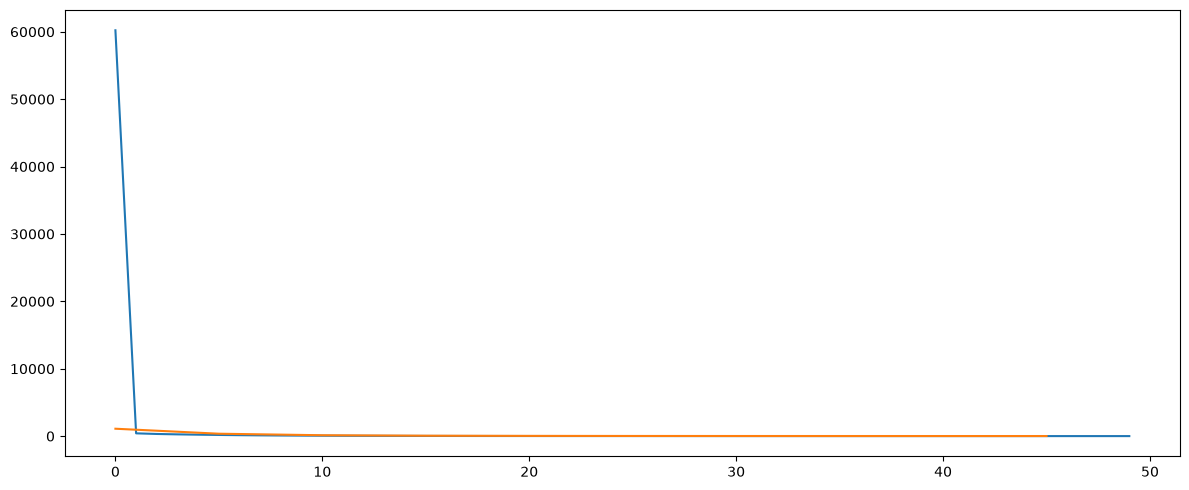

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 1, figsize=(12, 5))

axs.plot(range(EPOCHS), train_losses)
axs.plot(range(0, EPOCHS, EVAL_STEP), eval_losses)

fig.tight_layout()
plt.show()

In [13]:
"""Inference time"""

from tabulate import tabulate

input, expected = X_te[4, :], Y_te[4, :]

model.eval()
preds = model(input).data.flatten()
expected = expected.data.flatten()

rows = []
for t, (exp, pred) in enumerate(zip(expected, preds)):
    diff = pred - exp
    pct_err = abs(diff) / abs(exp) * 100 if exp != 0 else float('nan')
    rows.append([t, f'{exp:.4f}', f'{pred:.4f}', f'{diff:+.4f}', f'{pct_err:.2f}%'])

print('-----------------------Test Values----------------------')
print(tabulate(
    rows,
    headers=['t', 'expected', 'predicted', 'diff', '% error'],
    tablefmt='rounded_outline',
    colalign=('center', 'right', 'right', 'right', 'right'),
))

-----------------------Test Values----------------------
╭─────┬────────────┬─────────────┬─────────┬───────────╮
│  t  │   expected │   predicted │    diff │   % error │
├─────┼────────────┼─────────────┼─────────┼───────────┤
│  0  │          7 │      5.6429 │ -1.3571 │    19.39% │
│  1  │          9 │      7.8338 │ -1.1662 │    12.96% │
│  2  │         11 │     10.0246 │ -0.9754 │     8.87% │
│  3  │         13 │     12.2155 │ -0.7845 │     6.03% │
│  4  │         15 │     14.4063 │ -0.5937 │     3.96% │
╰─────┴────────────┴─────────────┴─────────┴───────────╯


In [14]:
input, expected = X_tr[2, :], Y_tr[2, :]

model.eval()
preds = model(input).data.flatten()
expected = expected.data.flatten()

rows = []
for t, (exp, pred) in enumerate(zip(expected, preds)):
    diff = pred - exp
    pct_err = abs(diff) / abs(exp) * 100 if exp != 0 else float('nan')
    rows.append([t, f'{exp:.4f}', f'{pred:.4f}', f'{diff:+.4f}', f'{pct_err:.2f}%'])

print('-----------------------Train Values----------------------')
print(tabulate(
    rows,
    headers=['t', 'expected', 'predicted', 'diff', '% error'],
    tablefmt='rounded_outline',
    colalign=('center', 'right', 'right', 'right', 'right'),
))

-----------------------Train Values----------------------
╭─────┬────────────┬─────────────┬─────────┬───────────╮
│  t  │   expected │   predicted │    diff │   % error │
├─────┼────────────┼─────────────┼─────────┼───────────┤
│  0  │       15.4 │     12.2155 │ -3.1845 │    20.68% │
│  1  │       19.8 │     17.0353 │ -2.7647 │    13.96% │
│  2  │       24.2 │     21.8552 │ -2.3448 │     9.69% │
│  3  │       28.6 │      26.675 │  -1.925 │     6.73% │
│  4  │         33 │     31.4949 │ -1.5051 │     4.56% │
╰─────┴────────────┴─────────────┴─────────┴───────────╯
